# Esquemático de referência

A figura abaixo representa o circuito-base usado na análise.


<center>
    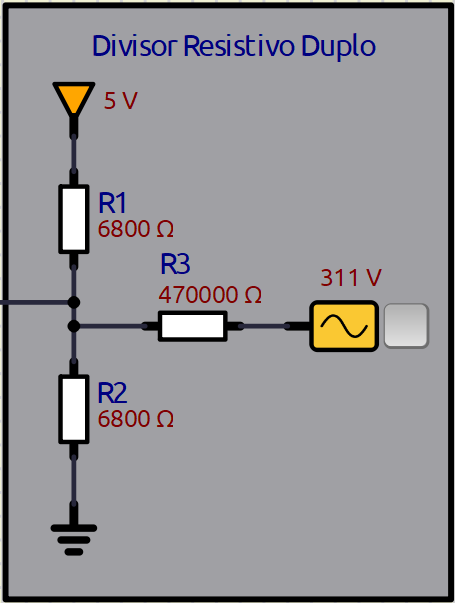
</center>

# Formulação do problema

## Conversão RMS → pico
Para trabalhar com o valor instantâneo máximo do sinal de entrada, usamos:

\[
V_{pico} = V_{RMS}\sqrt{2}
\]

Para **220 V RMS**:

\[
V_{pico} \approx 311{,}13\ \text{V}
\]

A partir desse valor, procuramos um circuito que gere uma saída aproximadamente entre **0 V** e **5 V**.


# Estratégia computacional

A solução foi organizada em 4 etapas:

1. **Definir os parâmetros** do problema;
2. **Gerar uma lista de resistores comerciais**;
3. **Calcular ganho e offset** para cada combinação;
4. **Filtrar circuitos válidos** por critérios elétricos e de saída.

Nesta versão, o notebook foi estruturado para conversão em slides via `nbconvert --to slides`.


In [ ]:
import math
import random
import pandas as pd

# Reprodutibilidade para a apresentação
random.seed(42)

# 1) Parâmetros do problema

Definimos:
- faixa desejada de saída;
- tensão de entrada;
- número de tentativas da busca aleatória.


In [ ]:
# Saída desejada: [máxima, mínima]
saida_desejada = [5.0, 0.0]

# Entrada em RMS
entrada_rms = 220.0

# Número máximo de tentativas
max_tentativas = 8000

print(f"Saída desejada: {saida_desejada[1]} V a {saida_desejada[0]} V")
print(f"Entrada RMS: {entrada_rms} V")
print(f"Máximo de tentativas: {max_tentativas}")

# 2) Preparação do sinal de entrada

Se a entrada for informada como um único valor RMS, montamos automaticamente os dois extremos:
- semiciclo positivo;
- semiciclo negativo.

Depois, convertemos RMS para pico.


In [ ]:
# Se a entrada for apenas um número, criamos [positivo, negativo]
if isinstance(entrada_rms, (int, float)):
    entrada_rms = [entrada_rms, -entrada_rms]

# Converte RMS para pico
entrada_pico = [valor * math.sqrt(2) for valor in entrada_rms]

print("Entrada RMS:", entrada_rms)
print("Entrada em pico:", entrada_pico)

# 3) Resistores comerciais

Usamos uma série discreta de valores base e multiplicamos por décadas para gerar uma biblioteca de resistores disponíveis para a busca.


In [ ]:
valores_base = [10, 11, 12, 13, 15, 16, 18, 20, 22, 24, 27,
                30, 33, 36, 39, 43, 47, 51, 56, 62, 68, 75, 82]

decadas = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]

resistores_comerciais = []

for base in valores_base:
    for decada in decadas:
        resistores_comerciais.append(base * decada)

print("Quantidade de resistores disponíveis:", len(resistores_comerciais))
print("Amostra inicial:", resistores_comerciais[:20])

# 4) Funções auxiliares

Criamos funções para calcular:
- associação em paralelo;
- ganho CA real;
- offset CC;
- saída final;
- validação do circuito.


In [ ]:
def paralelo(r1, r2):
    """Calcula o equivalente em paralelo de dois resistores."""
    return (r1 * r2) / (r1 + r2)


def calcular_ganho_ca_real(r1, r2, r3):
    """Calcula o ganho CA real do circuito."""
    r1_paralelo_r2 = paralelo(r1, r2)
    return r1_paralelo_r2 / (r3 + r1_paralelo_r2)


def calcular_offset_cc(r1, r2, r3, tensao_cc):
    """Calcula o offset CC na saída."""
    r3_paralelo_r2 = paralelo(r3, r2)
    return (r3_paralelo_r2 / (r1 + r3_paralelo_r2)) * tensao_cc


def calcular_ganho_ca_ideal(tensao_cc, tensao_ca_pico):
    """Calcula o ganho CA ideal de referência."""
    return (tensao_cc / 2.0) / tensao_ca_pico


def calcular_saida_final(valor_cc, ganho_ca, entrada_pico):
    """Calcula a saída máxima e mínima."""
    vout_max = valor_cc + ganho_ca * entrada_pico[0]
    vout_min = valor_cc + ganho_ca * entrada_pico[1]
    return [vout_max, vout_min]


def circuito_valido(r1, r2, r3, ganho_ca_real, ganho_ca_ideal, vout, saida_desejada):
    """Verifica se o circuito atende aos critérios desejados."""
    return (
        r3 < 500_000 and
        max(saida_desejada) / (r1 + r2) < 0.001 and
        ganho_ca_real <= ganho_ca_ideal and
        max(vout) >= 0.90 * max(saida_desejada) and
        min(vout) >= 0.04 * min(saida_desejada)
    )

# 5) Ganho CA ideal

O ganho ideal serve como referência para avaliar se a atenuação da rede resistiva está coerente com a faixa de saída desejada.


In [ ]:
ganho_ca_ideal = calcular_ganho_ca_ideal(
    tensao_cc=max(saida_desejada),
    tensao_ca_pico=max(entrada_pico)
)

print("Saída desejada:", saida_desejada)
print("Entrada em pico:", entrada_pico)
print("Ganho CA ideal:", ganho_ca_ideal)

# 6) Busca aleatória por combinações

Agora sorteamos combinações de resistores comerciais e avaliamos:
- ganho real;
- offset;
- faixa final de saída;
- atendimento aos critérios do projeto.


In [ ]:
circuitos_encontrados = []
combinacoes_registradas = set()

for _ in range(max_tentativas):
    # Sorteia os resistores
    r1 = random.choice(resistores_comerciais)
    r2 = r1  # Mantido igual ao código original
    r3 = random.choice(resistores_comerciais)

    # Calcula os parâmetros do circuito
    ganho_ca_real = calcular_ganho_ca_real(r1, r2, r3)
    valor_cc = calcular_offset_cc(r1, r2, r3, saida_desejada[0])
    vout = calcular_saida_final(valor_cc, ganho_ca_real, entrada_pico)

    # Testa se a combinação é válida
    if circuito_valido(r1, r2, r3, ganho_ca_real, ganho_ca_ideal, vout, saida_desejada):
        chave = (float(r1), float(r2), float(r3))
        if chave not in combinacoes_registradas:
            combinacoes_registradas.add(chave)
            circuitos_encontrados.append({
                "r1_ohm": float(r1),
                "r2_ohm": float(r2),
                "r3_ohm": float(r3),
                "vout_max_v": float(max(vout)),
                "vout_min_v": float(min(vout)),
                "ganho_ca_real": float(ganho_ca_real),
                "offset_cc_v": float(valor_cc),
            })

print("Quantidade de circuitos encontrados:", len(circuitos_encontrados))

# 7) Organização dos resultados

Para a apresentação, os resultados serão mostrados em tabela, ordenados pela maior saída máxima.


In [ ]:
df_resultados = pd.DataFrame(circuitos_encontrados)

if df_resultados.empty:
    print("Nenhum circuito válido foi encontrado.")
else:
    df_resultados = df_resultados.sort_values(
        by=["vout_max_v", "vout_min_v"],
        ascending=[False, False]
    ).reset_index(drop=True)

    df_resultados.index = df_resultados.index + 1
    df_resultados.index.name = "opcao"

    display(df_resultados.round(6))

# Leitura dos resultados

Ao final, temos uma lista de combinações que:
- usam valores comerciais;
- mantêm a saída próxima da faixa desejada;
- respeitam os critérios de ganho e limitação estabelecidos.

Em uma próxima etapa, ainda poderíamos:
- substituir a busca aleatória por busca exaustiva;
- introduzir tolerância dos resistores;
- incluir potência dissipada e segurança elétrica;
- comparar custo e robustez das soluções.


# Conversão para slides

Para converter este notebook em slides HTML, use no terminal:

```bash
jupyter nbconvert --to slides ININD1_TO1_CondicionadorSinais_slides.ipynb
```

Se quiser executar antes de converter:

```bash
jupyter nbconvert --to slides --execute ININD1_TO1_CondicionadorSinais_slides.ipynb
```
